In [1]:
import sys
sys.path.append("..")

from IPython.display import Image, display
from langgraph.graph import END, StateGraph

from catchup.rag.state import AgentState
from catchup.rag.conditional_edges import route_after_supervisor

async def _noop(*args, **kwargs):
    return {}

## Main Graph

`supervisor` → 5개 파이프라인으로 라우팅

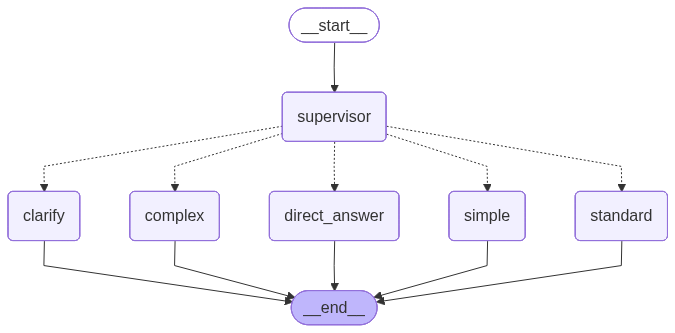

In [2]:
g = StateGraph(AgentState)
for name in ["supervisor", "direct_answer", "simple", "standard", "complex", "clarify"]:
    g.add_node(name, _noop)

g.set_entry_point("supervisor")
g.add_conditional_edges(
    "supervisor",
    route_after_supervisor,
    {
        "direct_answer": "direct_answer",
        "clarify": "clarify",
        "simple": "simple",
        "standard": "standard",
        "complex": "complex",
    },
)
for name in ["direct_answer", "simple", "standard", "complex", "clarify"]:
    g.add_edge(name, END)

main_graph = g.compile()
display(Image(main_graph.get_graph().draw_mermaid_png()))

## Simple Subgraph

SMALL 모델 2회 (rewrite + generate_vector_queries) + LARGE 스트림 1회 (generate_final_answer).

- `rewrite`: 원본 쿼리 정제
- `select_final_docs`: rerank 결과에서 K=10 컷오프 + 스트리밍 이벤트 발행 (essential bypass는 no-op)
- `merge_cache`: rerank 결과로 `doc_cache` overwrite + `search_turn_history`에 SearchTurnMeta 누적


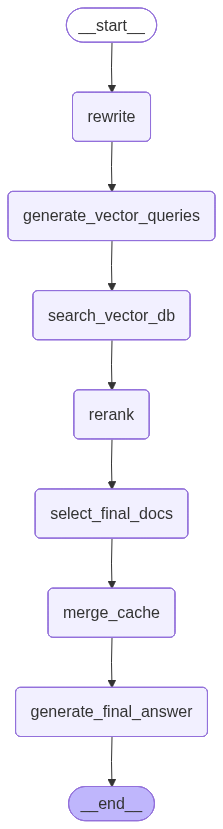

In [3]:
g = StateGraph(AgentState)
for name in ["rewrite", "generate_vector_queries", "search_vector_db", "rerank", "select_final_docs", "merge_cache", "generate_final_answer"]:
    g.add_node(name, _noop)

g.set_entry_point("rewrite")
g.add_edge("rewrite", "generate_vector_queries")
g.add_edge("generate_vector_queries", "search_vector_db")
g.add_edge("search_vector_db", "rerank")
g.add_edge("rerank", "select_final_docs")
g.add_edge("select_final_docs", "merge_cache")
g.add_edge("merge_cache", "generate_final_answer")
g.add_edge("generate_final_answer", END)

simple_graph = g.compile()
display(Image(simple_graph.get_graph().draw_mermaid_png()))


## Standard ReAct Subgraph

SMALL 모델, max_iter=4. `prepare_cache`로 이전 검색 결과를 agent iter-0에 제공.
agent가 cache만으로 답할 수 있으면 tool call 없이 종료.

- `prepare_cache`: hot cache + (선택적) 과거 턴 docs lazy fetch → `retrieved_docs`
  - `cache_turn_numbers=null` → hot cache만
  - `cache_turn_numbers=[N]` → Search N 턴 lazy fetch
- `extract_essential`: iteration_limit 도달 시 지금까지 수집한 docs에서 핵심 추출
- agent routing: `agent_stop_reason`으로 분기
  - `by_choice` → `collect_docs`
  - `iteration_limit` → `extract_essential` → `collect_docs`
  - tool_calls 있음 → `tool_executor`
  - 그 외 → `collect_docs`
- `select_final_docs`: K=15 컷오프, essential bypass (Pool B), 스트리밍 이벤트 발행
- `merge_cache`: rerank 결과로 `doc_cache` overwrite + `search_turn_history`에 SearchTurnMeta 누적


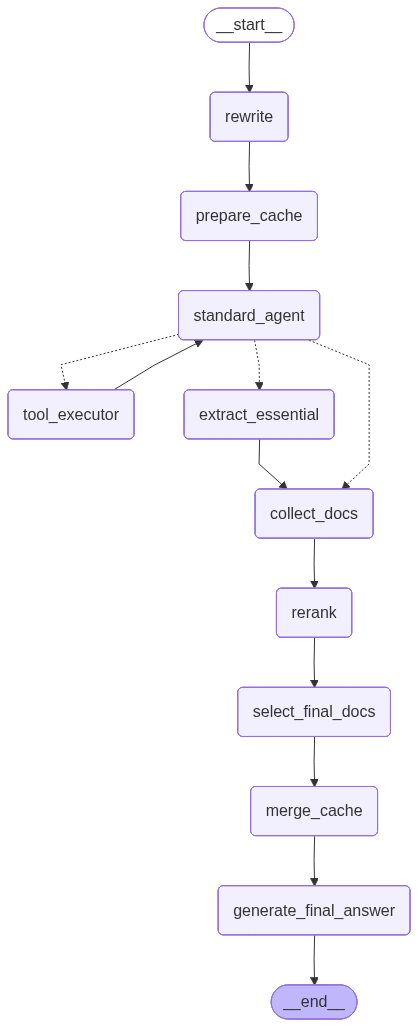

In [4]:
def _route_after_agent(state: AgentState) -> str:
    stop_reason = state.get("agent_stop_reason")
    if stop_reason == "by_choice":
        return "collect_docs"
    if stop_reason == "iteration_limit":
        return "extract_essential"
    messages = state.get("messages", [])
    last = messages[-1] if messages else None
    if last and getattr(last, "tool_calls", None):
        return "tool_executor"
    pipeline_plan = state.get("pipeline_plan")
    max_iterations = pipeline_plan.max_iterations if pipeline_plan else 4
    if state.get("agent_iteration", 0) >= max_iterations:
        return "extract_essential"
    return "collect_docs"


g = StateGraph(AgentState)
for name in ["rewrite", "prepare_cache", "standard_agent", "tool_executor", "extract_essential", "collect_docs", "rerank", "select_final_docs", "merge_cache", "generate_final_answer"]:
    g.add_node(name, _noop)

g.set_entry_point("rewrite")
g.add_edge("rewrite", "prepare_cache")
g.add_edge("prepare_cache", "standard_agent")
g.add_conditional_edges(
    "standard_agent",
    _route_after_agent,
    {"tool_executor": "tool_executor", "extract_essential": "extract_essential", "collect_docs": "collect_docs"},
)
g.add_edge("tool_executor", "standard_agent")
g.add_edge("extract_essential", "collect_docs")
g.add_edge("collect_docs", "rerank")
g.add_edge("rerank", "select_final_docs")
g.add_edge("select_final_docs", "merge_cache")
g.add_edge("merge_cache", "generate_final_answer")
g.add_edge("generate_final_answer", END)

standard_graph = g.compile()
display(Image(standard_graph.get_graph().draw_mermaid_png()))


## Complex ReAct Subgraph

SMALL 모델 (planner/agent), max_iter=8, Extended Thinking.
- Phase 0: `prepare_cache` — 이전 검색 결과 로드
  - cold cache (`retrieved_docs` 없음) → `complex_planner`로 직행
  - warm cache (`retrieved_docs` 있음) → `complex_agent` iter-0으로 (cache 평가)
- Phase 1: `complex_planner` — 검색 전략 수립 → `complex_agent`
- Phase 2: `complex_agent` ↔ `tool_executor` — Self-improving ReAct loop
  - `agent_stop_reason=by_choice` → `collect_docs`
  - `agent_stop_reason=iteration_limit` → `extract_essential` → `collect_docs`
  - tool_calls + `search_plan` 없음 → `complex_planner`
  - tool_calls + `search_plan` 있음 → `tool_executor`
- Phase 3: `collect_docs` → `rerank` → `select_final_docs` (K=20) → `merge_cache` → `generate_final_answer`
  - `merge_cache`: rerank 결과로 `doc_cache` overwrite + `search_turn_history`에 SearchTurnMeta 누적


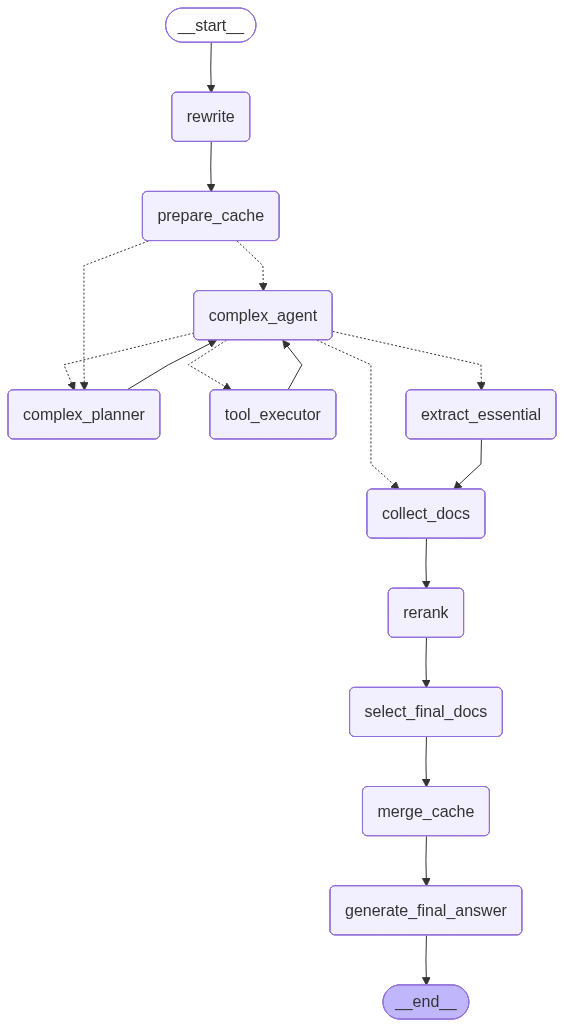

In [5]:
def _route_after_prepare_cache(state: AgentState) -> str:
    if not state.get("retrieved_docs"):
        return "complex_planner"
    return "complex_agent"


def _route_after_complex_agent(state: AgentState) -> str:
    stop_reason = state.get("agent_stop_reason")
    if stop_reason == "by_choice":
        return "collect_docs"
    if stop_reason == "iteration_limit":
        return "extract_essential"
    messages = state.get("messages", [])
    last = messages[-1] if messages else None
    if last and getattr(last, "tool_calls", None):
        if state.get("search_plan") is None:
            return "complex_planner"
        return "tool_executor"
    pipeline_plan = state.get("pipeline_plan")
    max_iterations = pipeline_plan.max_iterations if pipeline_plan else 8
    if state.get("agent_iteration", 0) >= max_iterations:
        return "extract_essential"
    return "collect_docs"


g = StateGraph(AgentState)
for name in [
    "rewrite", "prepare_cache", "complex_planner", "complex_agent",
    "tool_executor", "extract_essential",
    "collect_docs", "rerank", "select_final_docs", "merge_cache", "generate_final_answer",
]:
    g.add_node(name, _noop)

g.set_entry_point("rewrite")
g.add_edge("rewrite", "prepare_cache")
g.add_conditional_edges(
    "prepare_cache",
    _route_after_prepare_cache,
    {"complex_planner": "complex_planner", "complex_agent": "complex_agent"},
)
g.add_edge("complex_planner", "complex_agent")
g.add_conditional_edges(
    "complex_agent",
    _route_after_complex_agent,
    {
        "complex_planner": "complex_planner",
        "tool_executor": "tool_executor",
        "extract_essential": "extract_essential",
        "collect_docs": "collect_docs",
    },
)
g.add_edge("tool_executor", "complex_agent")
g.add_edge("extract_essential", "collect_docs")
g.add_edge("collect_docs", "rerank")
g.add_edge("rerank", "select_final_docs")
g.add_edge("select_final_docs", "merge_cache")
g.add_edge("merge_cache", "generate_final_answer")
g.add_edge("generate_final_answer", END)

complex_graph = g.compile()
display(Image(complex_graph.get_graph().draw_mermaid_png()))
